# Engineering test: Load SIIM checkpoint + run (Diff) CAM on one ISIC2018 image

Goal: verify that your local setup works end-to-end:
1) Read ISIC2018 CSV + image  
2) Preprocess to 640×640  
3) Load the SIIM EfficientNet-B4 checkpoint (with key remapping)  
4) Run inference and get top-2 classes (A, B)  
5) Generate:
   - Grad-CAM(A)
   - Grad-CAM(B)
   - Diff-CAM(A−B)  (core “Finer-CAM idea”: explain why A > B)

Notes:
- This is an **engineering test only**. The SIIM model’s 9 classes are not ISIC2018’s 7 classes.
- Use this notebook as a template. Later you’ll swap in your ISIC2018 7-class model checkpoint.


In [1]:
# --- Environment sanity check (Mac M1: MPS should be True)
import numpy as np
import torch

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("mps:", torch.backends.mps.is_available())

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)


numpy: 1.26.4
torch: 2.2.2
mps: True
Device: mps


## 1) Paths and imports

Adjust `IMG_DIR`, `CSV_PATH`, `CKPT_PATH` to match your repo.


In [2]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image

import timm
import torchvision.transforms as T
import torch.nn.functional as F

# --- repo paths (notebook is in /notebooks)
REPO_ROOT = Path("..")

# NOTE: your current temporary folder name
IMG_DIR  = REPO_ROOT / "data" / "isic2018_temp" / "images_train"
CSV_PATH = REPO_ROOT / "data" / "isic2018_temp" / "train_gt.csv"

# SIIM checkpoint (engineering test)
CKPT_PATH = REPO_ROOT / "external" / "weights" / "9c_b4ns_768_640_ext_15ep_best_fold0.pth"

print("IMG_DIR exists:", IMG_DIR.exists())
print("CSV_PATH exists:", CSV_PATH.exists())
print("CKPT_PATH exists:", CKPT_PATH.exists())


IMG_DIR exists: True
CSV_PATH exists: True
CKPT_PATH exists: True


## 2) Load one sample (CSV row → image)

The ISIC2018 Task3 CSV has column `image` (no `.jpg`). We append `.jpg`.


CSV columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
Selected image: ISIC_0024306
Image path: ../data/isic2018_temp/images_train/ISIC_0024306.jpg
Exists: True


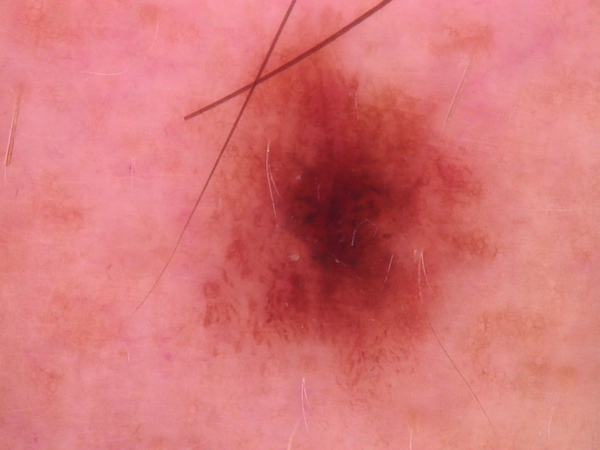

In [3]:
df = pd.read_csv(CSV_PATH)
print("CSV columns:", df.columns.tolist())
row = df.iloc[0]

image_id = row["image"]
img_path = IMG_DIR / f"{image_id}.jpg"

print("Selected image:", image_id)
print("Image path:", img_path)
print("Exists:", img_path.exists())

img = Image.open(img_path).convert("RGB")
img


## 3) Preprocess (resize to 640×640)

For the engineering test, we use a simple resize + ImageNet normalization.


In [4]:
import numpy as np
import cv2
import torch

IMAGE_SIZE = 640  # from checkpoint name "..._768_640_..."

preprocess = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

x = preprocess(img).unsqueeze(0)  # (1, 3, 640, 640)
print("Input tensor shape:", x.shape, x.dtype)

# RGB image for overlay (must match CAM resolution)
rgb = np.array(img).astype(np.float32) / 255.0
rgb_640 = cv2.resize(rgb, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)

input_tensor = x.to(device)


Input tensor shape: torch.Size([1, 3, 640, 640]) torch.float32


## 4) Load checkpoint + remap keys

Checkpoint keys include prefixes like:
- `module.` (DataParallel)
- `enet.` (their wrapper stored backbone under `self.enet`)
- `myfc.` (their classifier head)

We remap keys to match timm EfficientNet naming so `load_state_dict` is clean.


In [5]:
import torch

# Load checkpoint (often already a state_dict)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
state_dict = ckpt  # in your case it is an OrderedDict state_dict

# Find classifier dimension from "myfc.weight"
num_classes = None
for k in state_dict.keys():
    if "myfc.weight" in k:
        num_classes = state_dict[k].shape[0]
        print("Found classifier key:", k, "| num_classes:", num_classes)
        break

if num_classes is None:
    raise ValueError("Could not find myfc.weight in checkpoint.")

def remap_keys(sd):
    new_sd = {}
    for k, v in sd.items():
        # drop DataParallel prefix
        if k.startswith("module."):
            k2 = k[len("module."):]
        else:
            k2 = k

        # backbone stored under enet.*
        if k2.startswith("enet."):
            k2 = k2[len("enet."):]
        
        # classifier stored under myfc.*
        if k2.startswith("myfc."):
            k2 = "classifier." + k2[len("myfc."):]
        
        # ignore tracking buffers
        if "num_batches_tracked" in k2:
            continue
        
        new_sd[k2] = v
    return new_sd

state_dict_timm = remap_keys(state_dict)
print("Remapped keys sample:", list(state_dict_timm.keys())[:10])


Found classifier key: module.myfc.weight | num_classes: 9
Remapped keys sample: ['conv_stem.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'blocks.0.0.conv_dw.weight', 'blocks.0.0.bn1.weight', 'blocks.0.0.bn1.bias', 'blocks.0.0.bn1.running_mean', 'blocks.0.0.bn1.running_var']


## 5) Build model + load weights

We use timm model name `tf_efficientnet_b4_ns` (timm will map to its current internal name).


In [6]:
enet_type = "tf_efficientnet_b4_ns"

model = timm.create_model(enet_type, pretrained=False, num_classes=num_classes)
model.eval()

missing, unexpected = model.load_state_dict(state_dict_timm, strict=False)
print("Missing:", len(missing), "| Unexpected:", len(unexpected))
if len(missing) > 0: print("Missing sample:", missing[:10])
if len(unexpected) > 0: print("Unexpected sample:", unexpected[:10])

model = model.to(device)
print(model.__class__.__name__)


/Users/choekyelnyungmartsang/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b4_ns to current tf_efficientnet_b4.ns_jft_in1k.
  model = create_fn(


Missing: 0 | Unexpected: 0
EfficientNet


## 6) Predict and pick A (top-1) and B (top-2)

A and B are the classes we will contrast in Diff-CAM.


In [7]:
with torch.no_grad():
    logits = model(input_tensor)  # (1, C)

probs = torch.softmax(logits, dim=1)[0]
top2 = torch.topk(probs, k=2).indices.cpu().tolist()
A, B = top2[0], top2[1]

print("Logits:", logits)
print("Top-3 probs:", torch.topk(probs, 3).values.cpu().numpy())
print("A (top1):", A, "| B (top2):", B)


Logits: tensor([[-8.0205, -5.0924, -2.6346, -4.9309, -7.6849, -6.5421,  5.2452,  8.6590,
         -4.5697]], device='mps:0')
Top-3 probs: [9.6811658e-01 3.1866975e-02 1.2056074e-05]
A (top1): 7 | B (top2): 6


## 7) Grad-CAM and Diff-CAM (mini “Finer-CAM” demo)

- Grad-CAM(A): evidence for class A  
- Grad-CAM(B): evidence for class B  
- Diff-CAM(A−B): evidence that makes the model prefer A over B  

We use `model.conv_head` as target layer (stable for EfficientNet).


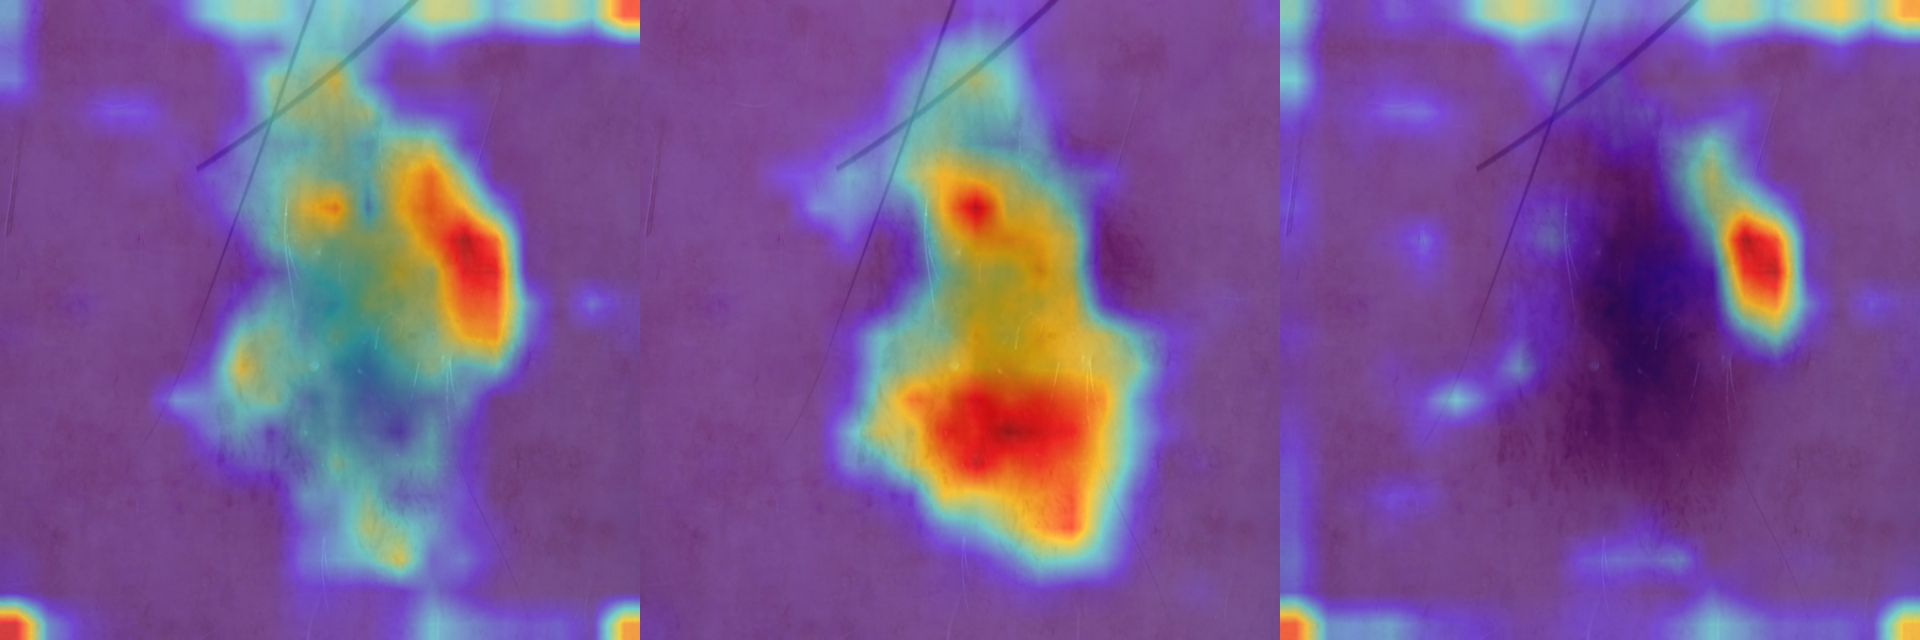

In [8]:
from pytorch_grad_cam import GradCAM, LayerCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

# Target layer for CAM (EfficientNet)
target_layers = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layers)

class LogitDiffTarget:
    """Target for CAM: logit[A] - logit[B]."""
    def __init__(self, a: int, b: int):
        self.a, self.b = a, b
    def __call__(self, o):
        # pytorch-grad-cam passes o as (C,) for single-image runs
        return o[self.a] - o[self.b]

# Grad-CAM(A)
cam_A = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(A)])[0]
vis_A = show_cam_on_image(rgb_640, cam_A, use_rgb=True)

# Grad-CAM(B)
cam_B = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(B)])[0]
vis_B = show_cam_on_image(rgb_640, cam_B, use_rgb=True)

# Diff-CAM(A - B)
cam_diff = cam(input_tensor=input_tensor, targets=[LogitDiffTarget(A, B)])[0]
vis_diff = show_cam_on_image(rgb_640, cam_diff, use_rgb=True)

Image.fromarray(np.hstack([vis_A, vis_B, vis_diff]))


## 8) Optional: LayerCAM diff (often sharper)

If you want a more detailed map, LayerCAM can be sharper than Grad-CAM.


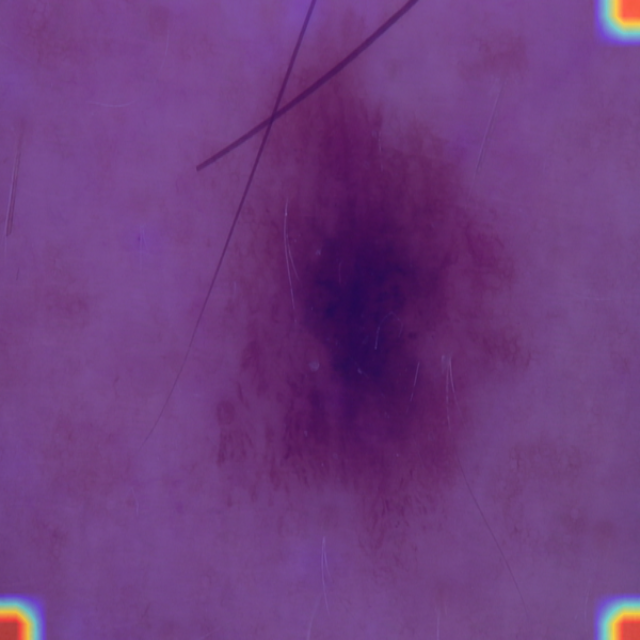

In [9]:
layercam = LayerCAM(model=model, target_layers=[model.blocks[-1][-1].conv_pwl])
cam_diff_l = layercam(input_tensor=input_tensor, targets=[LogitDiffTarget(A, B)])[0]
vis_diff_l = show_cam_on_image(rgb_640, cam_diff_l, use_rgb=True)
Image.fromarray(vis_diff_l)


## 9) Save outputs (optional)

Saves the three-panel demo and the diff maps.


In [11]:
from pathlib import Path
import json

OUT_DIR = REPO_ROOT / "outputs" / "debug_cam"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Image.fromarray(np.hstack([vis_A, vis_B, vis_diff])).save(OUT_DIR / f"{image_id}_A_B_DIFF_gradcam.png")
Image.fromarray(vis_diff_l).save(OUT_DIR / f"{image_id}_DIFF_layercam.png")

# Save minimal metadata
meta = {
    "image_id": image_id,
    "checkpoint": CKPT_PATH.name,
    "enet_type": enet_type,
    "image_size": IMAGE_SIZE,
    "A_top1": int(A),
    "B_top2": int(B),
    "probs_top3": torch.topk(probs, 3).values.cpu().tolist(),
    "device": device,
}
(meta_path := OUT_DIR / f"{image_id}_meta.json").write_text(json.dumps(meta, indent=2))
print("Saved to:", OUT_DIR)
print("Meta:", meta_path)


Saved to: ../outputs/debug_cam
Meta: ../outputs/debug_cam/ISIC_0024306_meta.json


# Playground 1

In [14]:
from pathlib import Path
import pandas as pd

ROOT = Path("..")
HAM_CSV = ROOT / 'data' / 'HAM10000' / 'HAM10000.csv'

TEST = ROOT / 'data' / 'ISIC2018_Task1' / 'ISIC2018_Task1_Test_GroundTruth'
TRAIN = ROOT / 'data' / 'ISIC2018_Task1' / 'ISIC2018_Task1_Training_GroundTruth'
VAL = ROOT / 'data' / 'ISIC2018_Task1' / 'ISIC2018_Task1_Validation_GroundTruth'

print('HAM input:', HAM_CSV)
print('TEST output:', TEST)
print('TRAIN output:', TRAIN)
print('VAL output:', VAL)

HAM input: ../data/HAM10000/HAM10000.csv
TEST output: ../data/ISIC2018_Task1/ISIC2018_Task1_Test_GroundTruth
TRAIN output: ../data/ISIC2018_Task1/ISIC2018_Task1_Training_GroundTruth
VAL output: ../data/ISIC2018_Task1/ISIC2018_Task1_Validation_GroundTruth


In [ ]:
# 1) Load HAM csv
# ----------------------------
ham_df = pd.read_csv(HAM_CSV)

print("HAM csv loaded:", HAM_CSV)
print("Shape:", ham_df.shape)
print("Columns:", list(ham_df.columns))
display(ham_df.head())

HAM csv loaded: ../data/HAM10000/HAM10000.csv
Shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old


In [ ]:
# 2) Check required columns
# ----------------------------
required_cols = ["image_id"]
missing_cols = [c for c in required_cols if c not in ham_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in HAM csv: {missing_cols}")

# fallback logic for split / class columns
split_col = "split" if "split" in ham_df.columns else None
class_col = "label" if "label" in ham_df.columns else ("dx" if "dx" in ham_df.columns else None)
image_col = "image" if "image" in ham_df.columns else None

print("Using split column:", split_col)
print("Using class column:", class_col)
print("Using image column:", image_col)

Using split column: split
Using class column: label
Using image column: image


In [ ]:
# 3) Build mask index from ISIC folders
# ----------------------------
mask_dirs = {
    "ISIC2018_Task1_Training_GroundTruth": TRAIN,
    "ISIC2018_Task1_Validation_GroundTruth": VAL,
    "ISIC2018_Task1_Test_GroundTruth": TEST,
}

mask_records = []

for source_name, folder in mask_dirs.items():
    if not folder.exists():
        print(f"[WARNING] Folder not found: {folder}")
        continue

    png_files = sorted(folder.glob("*.png"))
    print(f"{source_name}: found {len(png_files)} png masks")

    for p in png_files:
        fname = p.name
        suffix = "_segmentation.png"

        if fname.endswith(suffix):
            image_id = fname[:-len(suffix)]
        else:
            image_id = p.stem

        mask_records.append({
            "image_id": image_id,
            "mask_path": str(p.resolve()),
            "mask_source": source_name
        })

mask_index_df = pd.DataFrame(mask_records)

print("\nTotal masks indexed:", len(mask_index_df))
display(mask_index_df.head())

if mask_index_df.empty:
    raise ValueError("No masks were indexed. Check your folder paths.")

# check duplicate image_ids across folders
dups = mask_index_df[mask_index_df.duplicated(subset=["image_id"], keep=False)].sort_values("image_id")
print("Duplicate image_id entries in mask index:", len(dups))
if len(dups) > 0:
    display(dups.head(20))

# keep first occurrence if duplicates exist
mask_index_df = mask_index_df.drop_duplicates(subset=["image_id"], keep="first").copy()

ISIC2018_Task1_Training_GroundTruth: found 2594 png masks
ISIC2018_Task1_Validation_GroundTruth: found 100 png masks
ISIC2018_Task1_Test_GroundTruth: found 1000 png masks

Total masks indexed: 3694


,image_id,mask_path,mask_source
0,ISIC_0000000,/Users/choekyelnyungmartsang/Developer/master-...,ISIC2018_Task1_Training_GroundTruth
1,ISIC_0000001,/Users/choekyelnyungmartsang/Developer/master-...,ISIC2018_Task1_Training_GroundTruth
2,ISIC_0000003,/Users/choekyelnyungmartsang/Developer/master-...,ISIC2018_Task1_Training_GroundTruth
3,ISIC_0000004,/Users/choekyelnyungmartsang/Developer/master-...,ISIC2018_Task1_Training_GroundTruth
4,ISIC_0000006,/Users/choekyelnyungmartsang/Developer/master-...,ISIC2018_Task1_Training_GroundTruth


Duplicate image_id entries in mask index: 0


In [ ]:
# 4) Merge HAM rows with mask index
# ----------------------------
result_df = ham_df.copy()

result_df = result_df.merge(
    mask_index_df,
    on="image_id",
    how="left"
)

result_df["mask_found"] = result_df["mask_path"].notna().astype(int)

# standardized output columns
result_df["split_out"] = result_df[split_col] if split_col is not None else "unknown"
result_df["class_label_out"] = result_df[class_col] if class_col is not None else "unknown"

# reorder useful columns
ordered_cols = [
    "image_id",
    "split_out",
    "class_label_out",
    "mask_found",
    "mask_path",
    "mask_source"
]

extra_cols = [c for c in ["lesion_id", "image", "dx", "label", "split"] if c in result_df.columns]
ordered_cols = extra_cols + [c for c in ordered_cols if c not in extra_cols]

result_view = result_df[ordered_cols].copy()

print("\nMerged result preview:")
display(result_view.head(20))


Merged result preview:


,lesion_id,image,dx,label,split,image_id,split_out,class_label_out,mask_found,mask_path,mask_source
0,HAM_0000118,ISIC_0027419.jpg,bkl,2,train,ISIC_0027419,train,2,0,NaN,NaN
1,HAM_0002730,ISIC_0026769.jpg,bkl,2,train,ISIC_0026769,train,2,0,NaN,NaN
2,HAM_0002730,ISIC_0025661.jpg,bkl,2,train,ISIC_0025661,train,2,0,NaN,NaN
3,HAM_0001466,ISIC_0031633.jpg,bkl,2,train,ISIC_0031633,train,2,0,NaN,NaN
4,HAM_0001466,ISIC_0027850.jpg,bkl,2,train,ISIC_0027850,train,2,0,NaN,NaN
5,HAM_0002761,ISIC_0029176.jpg,bkl,2,train,ISIC_0029176,train,2,0,NaN,NaN
6,HAM_0001396,ISIC_0025276.jpg,bkl,2,train,ISIC_0025276,train,2,0,NaN,NaN
7,HAM_0001949,ISIC_0025767.jpg,bkl,2,train,ISIC_0025767,train,2,0,NaN,NaN
8,HAM_0001949,ISIC_0032417.jpg,bkl,2,train,ISIC_0032417,train,2,0,NaN,NaN
9,HAM_0007207,ISIC_0031326.jpg,bkl,2,train,ISIC_0031326,train,2,0,NaN,NaN


In [ ]:
# 5) Summary tables
# ----------------------------
print("\n=== Split-wise mask coverage ===")
split_summary = (
    result_df
    .groupby("split_out", dropna=False)
    .agg(
        total_images=("image_id", "count"),
        masks_found=("mask_found", "sum")
    )
    .reset_index()
)
split_summary["coverage_pct"] = (100 * split_summary["masks_found"] / split_summary["total_images"]).round(2)
display(split_summary)

print("\n=== Class-wise mask coverage ===")
class_summary = (
    result_df
    .groupby(["split_out", "class_label_out"], dropna=False)
    .agg(
        total_images=("image_id", "count"),
        masks_found=("mask_found", "sum")
    )
    .reset_index()
)
class_summary["coverage_pct"] = (100 * class_summary["masks_found"] / class_summary["total_images"]).round(2)
display(class_summary.sort_values(["split_out", "class_label_out"]))


=== Split-wise mask coverage ===


,split_out,total_images,masks_found,coverage_pct
0,test,1232,0,0.0
1,train,8207,0,0.0
2,trainisic,1,0,0.0
3,val,575,0,0.0



=== Class-wise mask coverage ===


,split_out,class_label_out,total_images,masks_found,coverage_pct
0,test,0,35,0,0.0
1,test,1,44,0,0.0
2,test,2,107,0,0.0
3,test,3,8,0,0.0
4,test,4,70,0,0.0
5,test,5,951,0,0.0
6,test,6,17,0,0.0
7,train,0,273,0,0.0
8,train,1,448,0,0.0
9,train,2,941,0,0.0


In [ ]:
# 6) Save outputs
# ----------------------------
out_dir = ROOT / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

availability_csv = out_dir / "ham_mask_availability.csv"
split_csv = out_dir / "ham_mask_split_summary.csv"
class_csv = out_dir / "ham_mask_class_summary.csv"

result_view.to_csv(availability_csv, index=False)
split_summary.to_csv(split_csv, index=False)
class_summary.to_csv(class_csv, index=False)

print("\nSaved:")
print(" -", availability_csv)
print(" -", split_csv)
print(" -", class_csv)


Saved:
 - ../outputs/ham_mask_availability.csv
 - ../outputs/ham_mask_split_summary.csv
 - ../outputs/ham_mask_class_summary.csv


In [ ]:
# 7) Quick answer to your 3 Phase-1 questions
# ----------------------------
print("\n=== Quick answers ===")
print("1) Train/val/test mask counts:")
display(split_summary)

print("2) Are masks available for all classes or mostly some images?")
display(class_summary.sort_values(["split_out", "coverage_pct"], ascending=[True, False]).head(30))

print("3) Exact image-id matching works by image_id <-> mask filename stem.")
print("   Example: ISIC_0027419 <-> ISIC_0027419_segmentation.png")


=== Quick answers ===
1) Train/val/test mask counts:


,split_out,total_images,masks_found,coverage_pct
0,test,1232,0,0.0
1,train,8207,0,0.0
2,trainisic,1,0,0.0
3,val,575,0,0.0


2) Are masks available for all classes or mostly some images?


,split_out,class_label_out,total_images,masks_found,coverage_pct
0,test,0,35,0,0.0
1,test,1,44,0,0.0
2,test,2,107,0,0.0
3,test,3,8,0,0.0
4,test,4,70,0,0.0
5,test,5,951,0,0.0
6,test,6,17,0,0.0
7,train,0,273,0,0.0
8,train,1,448,0,0.0
9,train,2,941,0,0.0


3) Exact image-id matching works by image_id <-> mask filename stem.
   Example: ISIC_0027419 <-> ISIC_0027419_segmentation.png


In [12]:
print("=== Examples with masks found ===")
display(result_view[result_view["mask_found"] == 1].head(20))

print("=== Examples with no mask found ===")
display(result_view[result_view["mask_found"] == 0].head(20))

print("Total matched:", int(result_view["mask_found"].sum()))
print("Total unmatched:", int((result_view["mask_found"] == 0).sum()))

=== Examples with masks found ===


,lesion_id,image,dx,label,split,image_id,split_out,class_label_out,mask_found,mask_path,mask_source


=== Examples with no mask found ===


,lesion_id,image,dx,label,split,image_id,split_out,class_label_out,mask_found,mask_path,mask_source
0,HAM_0000118,ISIC_0027419.jpg,bkl,2,train,ISIC_0027419,train,2,0,NaN,NaN
1,HAM_0002730,ISIC_0026769.jpg,bkl,2,train,ISIC_0026769,train,2,0,NaN,NaN
2,HAM_0002730,ISIC_0025661.jpg,bkl,2,train,ISIC_0025661,train,2,0,NaN,NaN
3,HAM_0001466,ISIC_0031633.jpg,bkl,2,train,ISIC_0031633,train,2,0,NaN,NaN
4,HAM_0001466,ISIC_0027850.jpg,bkl,2,train,ISIC_0027850,train,2,0,NaN,NaN
5,HAM_0002761,ISIC_0029176.jpg,bkl,2,train,ISIC_0029176,train,2,0,NaN,NaN
6,HAM_0001396,ISIC_0025276.jpg,bkl,2,train,ISIC_0025276,train,2,0,NaN,NaN
7,HAM_0001949,ISIC_0025767.jpg,bkl,2,train,ISIC_0025767,train,2,0,NaN,NaN
8,HAM_0001949,ISIC_0032417.jpg,bkl,2,train,ISIC_0032417,train,2,0,NaN,NaN
9,HAM_0007207,ISIC_0031326.jpg,bkl,2,train,ISIC_0031326,train,2,0,NaN,NaN


Total matched: 0
Total unmatched: 10015


# Playground 2

In [35]:
from pathlib import Path
import pandas as pd

ROOT = Path("..")

# ----------------------------
# Task 1 mask folders
# ----------------------------
T1_TRAIN_MASKS = ROOT / 'data' / 'ISIC2018_Task1' / 'Training_GroundTruth'
T1_VAL_MASKS   = ROOT / "data" / 'ISIC2018_Task1' / "Validation_GroundTruth"
T1_TEST_MASKS  = ROOT / "data" / 'ISIC2018_Task1' / "Test_GroundTruth"

# ----------------------------
# Task 3 classification csvs
# ----------------------------
T3_TRAIN_CSV = ROOT / "data" / "isic2018" / "train_gt.csv"
T3_VAL_CSV   = ROOT / "data" / "isic2018" / "val_gt.csv"
T3_TEST_CSV  = ROOT / "data" / "isic2018" / "test_gt.csv"

print("Task 1 mask folders:")
print(" - TRAIN:", T1_TRAIN_MASKS, "| exists:", T1_TRAIN_MASKS.exists())
print(" - VAL:  ", T1_VAL_MASKS,   "| exists:", T1_VAL_MASKS.exists())
print(" - TEST: ", T1_TEST_MASKS,  "| exists:", T1_TEST_MASKS.exists())

print("\nTask 3 csv files:")
print(" - TRAIN:", T3_TRAIN_CSV, "| exists:", T3_TRAIN_CSV.exists())
print(" - VAL:  ", T3_VAL_CSV,   "| exists:", T3_VAL_CSV.exists())
print(" - TEST: ", T3_TEST_CSV,  "| exists:", T3_TEST_CSV.exists())

Task 1 mask folders:
 - TRAIN: ../data/ISIC2018_Task1/Training_GroundTruth | exists: True
 - VAL:   ../data/ISIC2018_Task1/Validation_GroundTruth | exists: True
 - TEST:  ../data/ISIC2018_Task1/Test_GroundTruth | exists: True

Task 3 csv files:
 - TRAIN: ../data/isic2018/train_gt.csv | exists: True
 - VAL:   ../data/isic2018/val_gt.csv | exists: True
 - TEST:  ../data/isic2018/test_gt.csv | exists: True


In [36]:
train_df = pd.read_csv(T3_TRAIN_CSV)
val_df   = pd.read_csv(T3_VAL_CSV)
test_df  = pd.read_csv(T3_TEST_CSV)

print("TRAIN shape:", train_df.shape)
print("VAL shape:  ", val_df.shape)
print("TEST shape: ", test_df.shape)

print("\nTRAIN columns:", list(train_df.columns))
print("VAL columns:  ", list(val_df.columns))
print("TEST columns: ", list(test_df.columns))

display(train_df.head())
display(val_df.head())
display(test_df.head())

TRAIN shape: (10015, 8)
VAL shape:   (193, 8)
TEST shape:  (1512, 8)

TRAIN columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
VAL columns:   ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
TEST columns:  ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0034321,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0034322,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0034323,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,ISIC_0034324,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0034325,0.0,1.0,0.0,0.0,0.0,0.0,0.0


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0034524,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0034525,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0034526,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,ISIC_0034527,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0034528,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [37]:
mask_dirs = {
    "train": T1_TRAIN_MASKS,
    "val": T1_VAL_MASKS,
    "test": T1_TEST_MASKS,
}

mask_rows = []

suffix = "_segmentation.png"

for split_name, folder in mask_dirs.items():
    pngs = sorted(folder.glob("*.png"))
    print(f"{split_name}: found {len(pngs)} masks")

    for p in pngs:
        fname = p.name
        if fname.endswith(suffix):
            image_id = fname[:-len(suffix)]
        else:
            image_id = p.stem

        mask_rows.append({
            "task1_split": split_name,
            "image_id": image_id,
            "mask_filename": fname,
            "mask_path": str(p.resolve())
        })

task1_masks_df = pd.DataFrame(mask_rows)

print("\nTask 1 total masks:", len(task1_masks_df))
print("Unique Task 1 image_ids:", task1_masks_df["image_id"].nunique())

display(task1_masks_df.head())

train: found 2594 masks
val: found 100 masks
test: found 1000 masks

Task 1 total masks: 3694
Unique Task 1 image_ids: 3694


,task1_split,image_id,mask_filename,mask_path
0,train,ISIC_0000000,ISIC_0000000_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...
1,train,ISIC_0000001,ISIC_0000001_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...
2,train,ISIC_0000003,ISIC_0000003_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...
3,train,ISIC_0000004,ISIC_0000004_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...
4,train,ISIC_0000006,ISIC_0000006_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...


In [38]:
def prepare_task3_df(df, split_name):
    df = df.copy()

    if "image" not in df.columns:
        raise ValueError(f"'image' column not found in Task 3 {split_name} csv")

    df["image_id"] = df["image"].astype(str).str.replace(".jpg", "", regex=False)
    df["task3_split"] = split_name

    return df

task3_train_df = prepare_task3_df(train_df, "train")
task3_val_df   = prepare_task3_df(val_df, "val")
task3_test_df  = prepare_task3_df(test_df, "test")

task3_all_df = pd.concat(
    [task3_train_df, task3_val_df, task3_test_df],
    ignore_index=True
)

print("Task 3 total rows:", len(task3_all_df))
print("Unique Task 3 image_ids:", task3_all_df["image_id"].nunique())

display(task3_all_df.head())

Task 3 total rows: 11720
Unique Task 3 image_ids: 11720


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,image_id,task3_split
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024306,train
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024307,train
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024308,train
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024309,train
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024310,train


In [39]:
overlap_df = task1_masks_df.merge(
    task3_all_df,
    on="image_id",
    how="left"
)

overlap_df["has_task3_label"] = overlap_df["image"].notna().astype(int)

print("Task 1 masks total:", len(task1_masks_df))
print("Task 1 masks with Task 3 label match:", int(overlap_df["has_task3_label"].sum()))
print("Task 1 masks without Task 3 label match:", int((overlap_df["has_task3_label"] == 0).sum()))

display(overlap_df.head(2))

Task 1 masks total: 3694
Task 1 masks with Task 3 label match: 0
Task 1 masks without Task 3 label match: 3694


,task1_split,image_id,mask_filename,mask_path,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,task3_split,has_task3_label
0,train,ISIC_0000000,ISIC_0000000_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,train,ISIC_0000001,ISIC_0000001_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [40]:
split_summary = (
    overlap_df
    .groupby(["task1_split", "task3_split"], dropna=False)
    .agg(
        n_images=("image_id", "count")
    )
    .reset_index()
    .sort_values(["task1_split", "task3_split"])
)

print("=== Task 1 vs Task 3 split overlap ===")
display(split_summary)

summary_task1_only = (
    overlap_df
    .groupby("task1_split", dropna=False)
    .agg(
        total_task1_masks=("image_id", "count"),
        matched_to_task3=("has_task3_label", "sum")
    )
    .reset_index()
)

summary_task1_only["match_pct"] = (
    100 * summary_task1_only["matched_to_task3"] / summary_task1_only["total_task1_masks"]
).round(2)

print("\n=== Per Task 1 split match rate ===")
display(summary_task1_only)

=== Task 1 vs Task 3 split overlap ===


,task1_split,task3_split,n_images
0,test,NaN,1000
1,train,NaN,2594
2,val,NaN,100



=== Per Task 1 split match rate ===


,task1_split,total_task1_masks,matched_to_task3,match_pct
0,test,1000,0,0.0
1,train,2594,0,0.0
2,val,100,0,0.0


In [41]:
matched_df = overlap_df[overlap_df["has_task3_label"] == 1].copy()
unmatched_df = overlap_df[overlap_df["has_task3_label"] == 0].copy()

print("Matched examples:")
display(matched_df[[
    "image_id",
    "task1_split",
    "task3_split",
    "mask_filename",
    "image"
] + [c for c in task3_all_df.columns if c not in ["image", "image_id", "task3_split"]][:10]].head(20))

print("\nUnmatched examples:")
display(unmatched_df[[
    "image_id",
    "task1_split",
    "mask_filename"
]].head(2))

Matched examples:


,image_id,task1_split,task3_split,mask_filename,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC



Unmatched examples:


,image_id,task1_split,mask_filename
0,ISIC_0000000,train,ISIC_0000000_segmentation.png
1,ISIC_0000001,train,ISIC_0000001_segmentation.png


# Playground 3

In [ ]:
from pathlib import Path
import pandas as pd

ROOT = Path("..")

HAM_CSV = ROOT / "data" / "HAM10000" / "HAM10000.csv"
SEG_DIR = ROOT / "data" / "HAM10000_segmentations_lesion_tschandl"

print("HAM csv:", HAM_CSV, "| exists:", HAM_CSV.exists())
print("Seg dir :", SEG_DIR,  "| exists:", SEG_DIR.exists())

HAM_DIR   : ../data/HAM10000 | exists: True
IMAGE_DIR : ../data/HAM10000/images | exists: True
MASK_DIR  : ../data/HAM10000_segmentations_lesion_tschandl | exists: True
CSV_PATH  : ../data/HAM10000/ham_segmentation_overlap.csv | exists: True

Loaded CSV: ../data/HAM10000/ham_segmentation_overlap.csv
Shape: (10015, 10)
Columns: ['lesion_id', 'image_id', 'dx', 'label', 'split', 'image', 'mask_found', 'mask_filename', 'mask_path', 'mask_source']


,lesion_id,image_id,dx,label,split,image,mask_found,mask_filename,mask_path,mask_source
0,HAM_0000118,ISIC_0027419,bkl,2,train,ISIC_0027419.jpg,1,ISIC_0027419_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
1,HAM_0002730,ISIC_0026769,bkl,2,train,ISIC_0026769.jpg,1,ISIC_0026769_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
2,HAM_0002730,ISIC_0025661,bkl,2,train,ISIC_0025661.jpg,1,ISIC_0025661_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
3,HAM_0001466,ISIC_0031633,bkl,2,train,ISIC_0031633.jpg,1,ISIC_0031633_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
4,HAM_0001466,ISIC_0027850,bkl,2,train,ISIC_0027850.jpg,1,ISIC_0027850_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl


In [ ]:
ham_df = pd.read_csv(HAM_CSV)

print("HAM shape:", ham_df.shape)
print("HAM columns:", list(ham_df.columns))
display(ham_df.head())

if "image_id" not in ham_df.columns:
    raise ValueError("Expected column 'image_id' not found in HAM10000.csv")

Saved clean CSV: ../data/HAM10000/ham_segmentation_overlap_clean.csv


,lesion_id,image_id,dx,label,split,image,mask_found,image_rel_path,mask_rel_path,mask_filename,mask_source,image_abs_path,mask_abs_path
0,HAM_0000118,ISIC_0027419,bkl,2,train,ISIC_0027419.jpg,1,images/ISIC_0027419.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,ISIC_0027419_segmentation.png,HAM10000_segmentations_lesion_tschandl,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
1,HAM_0002730,ISIC_0026769,bkl,2,train,ISIC_0026769.jpg,1,images/ISIC_0026769.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,ISIC_0026769_segmentation.png,HAM10000_segmentations_lesion_tschandl,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
2,HAM_0002730,ISIC_0025661,bkl,2,train,ISIC_0025661.jpg,1,images/ISIC_0025661.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,ISIC_0025661_segmentation.png,HAM10000_segmentations_lesion_tschandl,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
3,HAM_0001466,ISIC_0031633,bkl,2,train,ISIC_0031633.jpg,1,images/ISIC_0031633.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,ISIC_0031633_segmentation.png,HAM10000_segmentations_lesion_tschandl,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
4,HAM_0001466,ISIC_0027850,bkl,2,train,ISIC_0027850.jpg,1,images/ISIC_0027850.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,ISIC_0027850_segmentation.png,HAM10000_segmentations_lesion_tschandl,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...


In [44]:
suffix = "_segmentation.png"

seg_rows = []
pngs = sorted(SEG_DIR.glob("*.png"))

print("Found segmentation pngs:", len(pngs))

for p in pngs:
    fname = p.name
    
    if fname.endswith(suffix):
        image_id = fname[:-len(suffix)]
    else:
        image_id = p.stem
    
    seg_rows.append({
        "image_id": image_id,
        "mask_filename": fname,
        "mask_path": str(p.resolve()),
        "mask_source": "HAM10000_segmentations_lesion_tschandl"
    })

seg_df = pd.DataFrame(seg_rows)

print("Indexed masks:", len(seg_df))
print("Unique image_ids in seg folder:", seg_df["image_id"].nunique())
display(seg_df.head())

dups = seg_df[seg_df.duplicated(subset=["image_id"], keep=False)].sort_values("image_id")
print("Duplicate image_ids in segmentation folder:", len(dups))
if len(dups) > 0:
    display(dups.head(20))

Found segmentation pngs: 10015
Indexed masks: 10015
Unique image_ids in seg folder: 10015


,image_id,mask_filename,mask_path,mask_source
0,ISIC_0024306,ISIC_0024306_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
1,ISIC_0024307,ISIC_0024307_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
2,ISIC_0024308,ISIC_0024308_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
3,ISIC_0024309,ISIC_0024309_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
4,ISIC_0024310,ISIC_0024310_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl


Duplicate image_ids in segmentation folder: 0


In [45]:
result_df = ham_df.merge(
    seg_df,
    on="image_id",
    how="left"
)

result_df["mask_found"] = result_df["mask_path"].notna().astype(int)

print("Total HAM rows:", len(result_df))
print("Matched masks :", int(result_df["mask_found"].sum()))
print("Unmatched     :", int((result_df["mask_found"] == 0).sum()))

display(result_df.head(20))

Total HAM rows: 10015
Matched masks : 10015
Unmatched     : 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group,mask_filename,mask_path,mask_source,mask_found
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old,ISIC_0027419_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old,ISIC_0026769_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old,ISIC_0025661_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old,ISIC_0031633_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old,ISIC_0027850_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
5,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,vidir_modern,train,2,ISIC_0029176.jpg,0,old,ISIC_0029176_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
6,HAM_0001396,ISIC_0025276,bkl,histo,55.0,female,trunk,vidir_modern,train,2,ISIC_0025276.jpg,0,old,ISIC_0025276_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
7,HAM_0001949,ISIC_0025767,bkl,histo,70.0,male,trunk,vidir_modern,train,2,ISIC_0025767.jpg,0,old,ISIC_0025767_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
8,HAM_0001949,ISIC_0032417,bkl,histo,70.0,male,trunk,vidir_modern,train,2,ISIC_0032417.jpg,0,old,ISIC_0032417_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1
9,HAM_0007207,ISIC_0031326,bkl,histo,65.0,male,back,vidir_modern,train,2,ISIC_0031326.jpg,0,old,ISIC_0031326_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,1


In [46]:
split_col = "split" if "split" in result_df.columns else None
class_col = "label" if "label" in result_df.columns else ("dx" if "dx" in result_df.columns else None)

if split_col is not None:
    split_summary = (
        result_df
        .groupby(split_col, dropna=False)
        .agg(
            total_images=("image_id", "count"),
            masks_found=("mask_found", "sum")
        )
        .reset_index()
    )
    split_summary["coverage_pct"] = (
        100 * split_summary["masks_found"] / split_summary["total_images"]
    ).round(2)

    print("=== Split-wise mask coverage ===")
    display(split_summary)

if split_col is not None and class_col is not None:
    class_summary = (
        result_df
        .groupby([split_col, class_col], dropna=False)
        .agg(
            total_images=("image_id", "count"),
            masks_found=("mask_found", "sum")
        )
        .reset_index()
    )
    class_summary["coverage_pct"] = (
        100 * class_summary["masks_found"] / class_summary["total_images"]
    ).round(2)

    print("=== Split + class-wise mask coverage ===")
    display(class_summary.sort_values([split_col, class_col]))

=== Split-wise mask coverage ===


,split,total_images,masks_found,coverage_pct
0,test,1232,1232,100.0
1,train,8207,8207,100.0
2,trainisic,1,1,100.0
3,val,575,575,100.0


=== Split + class-wise mask coverage ===


,split,label,total_images,masks_found,coverage_pct
0,test,0,35,35,100.0
1,test,1,44,44,100.0
2,test,2,107,107,100.0
3,test,3,8,8,100.0
4,test,4,70,70,100.0
5,test,5,951,951,100.0
6,test,6,17,17,100.0
7,train,0,273,273,100.0
8,train,1,448,448,100.0
9,train,2,941,941,100.0


In [47]:
print("=== Examples with masks found ===")
display(
    result_df[result_df["mask_found"] == 1][[
        c for c in [
            "lesion_id", "image_id", "image", "dx", "label", "split",
            "mask_filename", "mask_path", "mask_source"
        ] if c in result_df.columns
    ]].head(20)
)

print("=== Examples with no mask found ===")
display(
    result_df[result_df["mask_found"] == 0][[
        c for c in [
            "lesion_id", "image_id", "image", "dx", "label", "split"
        ] if c in result_df.columns
    ]].head(20)
)

=== Examples with masks found ===


,lesion_id,image_id,image,dx,label,split,mask_filename,mask_path,mask_source
0,HAM_0000118,ISIC_0027419,ISIC_0027419.jpg,bkl,2,train,ISIC_0027419_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
1,HAM_0002730,ISIC_0026769,ISIC_0026769.jpg,bkl,2,train,ISIC_0026769_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
2,HAM_0002730,ISIC_0025661,ISIC_0025661.jpg,bkl,2,train,ISIC_0025661_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
3,HAM_0001466,ISIC_0031633,ISIC_0031633.jpg,bkl,2,train,ISIC_0031633_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
4,HAM_0001466,ISIC_0027850,ISIC_0027850.jpg,bkl,2,train,ISIC_0027850_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
5,HAM_0002761,ISIC_0029176,ISIC_0029176.jpg,bkl,2,train,ISIC_0029176_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
6,HAM_0001396,ISIC_0025276,ISIC_0025276.jpg,bkl,2,train,ISIC_0025276_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
7,HAM_0001949,ISIC_0025767,ISIC_0025767.jpg,bkl,2,train,ISIC_0025767_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
8,HAM_0001949,ISIC_0032417,ISIC_0032417.jpg,bkl,2,train,ISIC_0032417_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
9,HAM_0007207,ISIC_0031326,ISIC_0031326.jpg,bkl,2,train,ISIC_0031326_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl


=== Examples with no mask found ===


,lesion_id,image_id,image,dx,label,split


In [ ]:
out_dir = ROOT / "data" / "HAM10000"
out_dir.mkdir(parents=True, exist_ok=True)

availability_cols = [
    c for c in [
        "lesion_id",
        "image_id",
        "dx",
        "label",
        "split",
        "image",
        "mask_found",
        "mask_filename",
        "mask_path",
        "mask_source",
    ] if c in result_df.columns
]

availability_df = result_df[availability_cols].copy()

out_csv = out_dir / "ham_segmentation_overlap.csv"
availability_df.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print("Rows :", len(availability_df))
display(availability_df.head(20))

Saved: ../outputs/ham10000_segmentation_overlap.csv
Rows : 10015


,lesion_id,image_id,dx,label,split,image,mask_found,mask_filename,mask_path,mask_source
0,HAM_0000118,ISIC_0027419,bkl,2,train,ISIC_0027419.jpg,1,ISIC_0027419_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
1,HAM_0002730,ISIC_0026769,bkl,2,train,ISIC_0026769.jpg,1,ISIC_0026769_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
2,HAM_0002730,ISIC_0025661,bkl,2,train,ISIC_0025661.jpg,1,ISIC_0025661_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
3,HAM_0001466,ISIC_0031633,bkl,2,train,ISIC_0031633.jpg,1,ISIC_0031633_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
4,HAM_0001466,ISIC_0027850,bkl,2,train,ISIC_0027850.jpg,1,ISIC_0027850_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
5,HAM_0002761,ISIC_0029176,bkl,2,train,ISIC_0029176.jpg,1,ISIC_0029176_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
6,HAM_0001396,ISIC_0025276,bkl,2,train,ISIC_0025276.jpg,1,ISIC_0025276_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
7,HAM_0001949,ISIC_0025767,bkl,2,train,ISIC_0025767.jpg,1,ISIC_0025767_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
8,HAM_0001949,ISIC_0032417,bkl,2,train,ISIC_0032417.jpg,1,ISIC_0032417_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl
9,HAM_0007207,ISIC_0031326,bkl,2,train,ISIC_0031326.jpg,1,ISIC_0031326_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import random

ROOT = Path("..")
DATA_ROOT = ROOT / "data"

HAM_DIR = DATA_ROOT / "HAM10000"
IMAGE_DIR = HAM_DIR / "images"   # change this if your jpgs are elsewhere
MASK_DIR = DATA_ROOT / "HAM10000_segmentations_lesion_tschandl"

CSV_PATH = HAM_DIR / "ham_segmentation_overlap.csv"

print("HAM_DIR   :", HAM_DIR, "| exists:", HAM_DIR.exists())
print("IMAGE_DIR :", IMAGE_DIR, "| exists:", IMAGE_DIR.exists())
print("MASK_DIR  :", MASK_DIR, "| exists:", MASK_DIR.exists())
print("CSV_PATH  :", CSV_PATH, "| exists:", CSV_PATH.exists())

df = pd.read_csv(CSV_PATH)
print("\nLoaded CSV:", CSV_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

In [ ]:
df = df.copy()

# image filename should already exist in column "image"
if "image" not in df.columns:
    raise ValueError("Column 'image' not found in CSV")

if "mask_filename" not in df.columns:
    raise ValueError("Column 'mask_filename' not found in CSV")

# store relative paths only
df["image_rel_path"] = "images/" + df["image"].astype(str)
df["mask_rel_path"] = "../HAM10000_segmentations_lesion_tschandl/" + df["mask_filename"].astype(str)

# optional: rebuild absolute paths in memory only for checking
df["image_abs_path"] = df["image_rel_path"].apply(lambda x: (HAM_DIR / x).resolve())
df["mask_abs_path"] = df["mask_rel_path"].apply(lambda x: (HAM_DIR / x).resolve())

clean_cols_first = [
    c for c in [
        "lesion_id", "image_id", "dx", "label", "split", "image",
        "mask_found", "image_rel_path", "mask_rel_path"
    ] if c in df.columns
]

other_cols = [c for c in df.columns if c not in clean_cols_first + ["mask_path"]]
clean_df = df[clean_cols_first + other_cols].copy()

CLEAN_CSV_PATH = HAM_DIR / "ham_segmentation_overlap_clean.csv"
clean_df.to_csv(CLEAN_CSV_PATH, index=False)

print("Saved clean CSV:", CLEAN_CSV_PATH)
display(clean_df.head())

In [51]:
if "mask_found" not in df.columns:
    raise ValueError("Column 'mask_found' not found in CSV")

if "split" not in df.columns:
    raise ValueError("Column 'split' not found in CSV")

coverage = (
    df.groupby("split", dropna=False)
      .agg(
          total_images=("image_id", "count"),
          masks_found=("mask_found", "sum")
      )
      .reset_index()
)

coverage["coverage_pct"] = (100 * coverage["masks_found"] / coverage["total_images"]).round(2)

print("=== 1) Coverage per split ===")
display(coverage)

print("Total rows:", len(df))
print("Total masks_found=1:", int(df["mask_found"].sum()))

=== 1) Coverage per split ===


,split,total_images,masks_found,coverage_pct
0,test,1232,1232,100.0
1,train,8207,8207,100.0
2,trainisic,1,1,100.0
3,val,575,575,100.0


Total rows: 10015
Total masks_found=1: 10015


In [52]:
df = df.copy()

df["image_exists"] = df["image_abs_path"].apply(lambda p: Path(p).exists())
df["mask_exists"] = df["mask_abs_path"].apply(lambda p: Path(p).exists())

print("=== 2) File existence check ===")

exist_summary = pd.DataFrame({
    "n_rows": [len(df)],
    "image_exists_sum": [int(df["image_exists"].sum())],
    "mask_exists_sum": [int(df["mask_exists"].sum())],
    "image_missing": [int((~df["image_exists"]).sum())],
    "mask_missing": [int((~df["mask_exists"]).sum())],
})

display(exist_summary)

print("\nMissing image examples:")
display(df.loc[~df["image_exists"], ["image_id", "image_rel_path"]].head(10))

print("\nMissing mask examples:")
display(df.loc[~df["mask_exists"], ["image_id", "mask_rel_path"]].head(10))

=== 2) File existence check ===


,n_rows,image_exists_sum,mask_exists_sum,image_missing,mask_missing
0,10015,10015,10015,0,0



Missing image examples:


,image_id,image_rel_path



Missing mask examples:


,image_id,mask_rel_path


In [53]:
random.seed(42)

valid_df = df[(df["image_exists"]) & (df["mask_exists"])].copy()

n_samples = min(5, len(valid_df))
sample_df = valid_df.sample(n=n_samples, random_state=42).copy()

rows = []

for _, row in sample_df.iterrows():
    image_path = Path(row["image_abs_path"])
    mask_path = Path(row["mask_abs_path"])
    
    try:
        with Image.open(image_path) as img:
            img_size = img.size
            img_mode = img.mode
        image_ok = True
    except Exception as e:
        img_size = None
        img_mode = None
        image_ok = False
        image_err = str(e)

    try:
        with Image.open(mask_path) as msk:
            mask_size = msk.size
            mask_mode = msk.mode
        mask_ok = True
    except Exception as e:
        mask_size = None
        mask_mode = None
        mask_ok = False
        mask_err = str(e)

    rows.append({
        "image_id": row["image_id"],
        "image_ok": image_ok,
        "mask_ok": mask_ok,
        "image_size_wh": img_size,
        "mask_size_wh": mask_size,
        "image_mode": img_mode,
        "mask_mode": mask_mode,
    })

sample_check_df = pd.DataFrame(rows)

print("=== 3) Random image-mask loading check ===")
display(sample_check_df)

=== 3) Random image-mask loading check ===


,image_id,image_ok,mask_ok,image_size_wh,mask_size_wh,image_mode,mask_mode
0,ISIC_0027832,True,True,"(600, 450)","(600, 450)",RGB,L
1,ISIC_0025209,True,True,"(600, 450)","(600, 450)",RGB,L
2,ISIC_0029998,True,True,"(600, 450)","(600, 450)",RGB,L
3,ISIC_0033068,True,True,"(600, 450)","(600, 450)",RGB,L
4,ISIC_0025261,True,True,"(600, 450)","(600, 450)",RGB,L


In [54]:
rows = []

valid_df = df[(df["image_exists"]) & (df["mask_exists"])].copy()

for _, row in valid_df.iterrows():
    image_path = Path(row["image_abs_path"])
    mask_path = Path(row["mask_abs_path"])

    try:
        with Image.open(image_path) as img:
            img_w, img_h = img.size
        with Image.open(mask_path) as msk:
            mask_w, mask_h = msk.size

        rows.append({
            "image_id": row["image_id"],
            "image_w": img_w,
            "image_h": img_h,
            "mask_w": mask_w,
            "mask_h": mask_h,
            "size_match": int((img_w == mask_w) and (img_h == mask_h))
        })
    except Exception as e:
        rows.append({
            "image_id": row["image_id"],
            "image_w": None,
            "image_h": None,
            "mask_w": None,
            "mask_h": None,
            "size_match": 0
        })

size_df = pd.DataFrame(rows)

print("=== 4) Resolution compatibility ===")

size_summary = pd.DataFrame({
    "checked_rows": [len(size_df)],
    "exact_size_match": [int(size_df["size_match"].sum())],
    "size_mismatch": [int((size_df["size_match"] == 0).sum())],
})

size_summary["match_pct"] = (100 * size_summary["exact_size_match"] / size_summary["checked_rows"]).round(2)

display(size_summary)

print("\nMismatched examples:")
display(size_df[size_df["size_match"] == 0].head(10))

=== 4) Resolution compatibility ===


,checked_rows,exact_size_match,size_mismatch,match_pct
0,10015,10015,0,100.0



Mismatched examples:


,image_id,image_w,image_h,mask_w,mask_h,size_match


In [55]:
def get_unique_values(mask_path):
    with Image.open(mask_path) as msk:
        arr = np.array(msk)
    return np.unique(arr)

valid_df = df[(df["mask_exists"])].copy()

# sample 10 masks for inspection
sample_n = min(10, len(valid_df))
sample_masks = valid_df.sample(n=sample_n, random_state=123)

sample_rows = []

for _, row in sample_masks.iterrows():
    mask_path = Path(row["mask_abs_path"])
    uniq = get_unique_values(mask_path)
    sample_rows.append({
        "image_id": row["image_id"],
        "n_unique_values": len(uniq),
        "unique_values_preview": uniq[:20].tolist(),
        "mask_abs_path": str(mask_path)
    })

sample_unique_df = pd.DataFrame(sample_rows)

print("=== 5) Binary mask sanity: sampled unique values ===")
display(sample_unique_df)

=== 5) Binary mask sanity: sampled unique values ===


,image_id,n_unique_values,unique_values_preview,mask_abs_path
0,ISIC_0031731,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
1,ISIC_0029286,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
2,ISIC_0027952,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
3,ISIC_0025582,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
4,ISIC_0024352,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
5,ISIC_0024886,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
6,ISIC_0031735,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
7,ISIC_0026310,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
8,ISIC_0027265,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...
9,ISIC_0029791,2,"[0, 255]",/Users/choekyelnyungmartsang/Developer/master-...


In [56]:
rows = []

for _, row in valid_df.iterrows():
    mask_path = Path(row["mask_abs_path"])
    try:
        uniq = get_unique_values(mask_path)
        uniq_set = set(uniq.tolist())

        # common valid binary-like cases
        is_binary_like = uniq_set.issubset({0, 1}) or uniq_set.issubset({0, 255})

        rows.append({
            "image_id": row["image_id"],
            "n_unique_values": len(uniq),
            "min_val": int(np.min(uniq)),
            "max_val": int(np.max(uniq)),
            "is_binary_like": int(is_binary_like),
            "unique_values_preview": str(uniq[:10].tolist())
        })
    except Exception as e:
        rows.append({
            "image_id": row["image_id"],
            "n_unique_values": None,
            "min_val": None,
            "max_val": None,
            "is_binary_like": 0,
            "unique_values_preview": f"ERROR: {e}"
        })

binary_df = pd.DataFrame(rows)

binary_summary = pd.DataFrame({
    "checked_masks": [len(binary_df)],
    "binary_like_masks": [int(binary_df["is_binary_like"].sum())],
    "non_binary_like_masks": [int((binary_df["is_binary_like"] == 0).sum())],
})

binary_summary["binary_like_pct"] = (
    100 * binary_summary["binary_like_masks"] / binary_summary["checked_masks"]
).round(2)

print("=== 5) Binary mask sanity: all masks summary ===")
display(binary_summary)

print("\nNon-binary-like examples:")
display(binary_df[binary_df["is_binary_like"] == 0].head(10))

=== 5) Binary mask sanity: all masks summary ===


,checked_masks,binary_like_masks,non_binary_like_masks,binary_like_pct
0,10015,10015,0,100.0



Non-binary-like examples:


,image_id,n_unique_values,min_val,max_val,is_binary_like,unique_values_preview


In [57]:
audit_df = df.merge(
    size_df[["image_id", "image_w", "image_h", "mask_w", "mask_h", "size_match"]],
    on="image_id",
    how="left"
).merge(
    binary_df[["image_id", "n_unique_values", "min_val", "max_val", "is_binary_like"]],
    on="image_id",
    how="left"
)

AUDIT_CSV = HAM_DIR / "ham_segmentation_overlap_audit.csv"
audit_df.to_csv(AUDIT_CSV, index=False)

print("Saved audit CSV:", AUDIT_CSV)
display(audit_df.head())

Saved audit CSV: ../data/HAM10000/ham_segmentation_overlap_audit.csv


,lesion_id,image_id,dx,label,split,image,mask_found,mask_filename,mask_path,mask_source,...,mask_exists,image_w,image_h,mask_w,mask_h,size_match,n_unique_values,min_val,max_val,is_binary_like
0,HAM_0000118,ISIC_0027419,bkl,2,train,ISIC_0027419.jpg,1,ISIC_0027419_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,...,True,600,450,600,450,1,2,0,255,1
1,HAM_0002730,ISIC_0026769,bkl,2,train,ISIC_0026769.jpg,1,ISIC_0026769_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,...,True,600,450,600,450,1,2,0,255,1
2,HAM_0002730,ISIC_0025661,bkl,2,train,ISIC_0025661.jpg,1,ISIC_0025661_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,...,True,600,450,600,450,1,2,0,255,1
3,HAM_0001466,ISIC_0031633,bkl,2,train,ISIC_0031633.jpg,1,ISIC_0031633_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,...,True,600,450,600,450,1,2,0,255,1
4,HAM_0001466,ISIC_0027850,bkl,2,train,ISIC_0027850.jpg,1,ISIC_0027850_segmentation.png,/Users/choekyelnyungmartsang/Developer/master-...,HAM10000_segmentations_lesion_tschandl,...,True,600,450,600,450,1,2,0,255,1


In [58]:
print("===== FINAL SANITY SUMMARY =====")

print("\n1) Coverage per split")
display(coverage)

print("\n2) Missing files")
display(exist_summary)

print("\n3) Random load check")
display(sample_check_df)

print("\n4) Resolution summary")
display(size_summary)

print("\n5) Binary mask summary")
display(binary_summary)

===== FINAL SANITY SUMMARY =====

1) Coverage per split


,split,total_images,masks_found,coverage_pct
0,test,1232,1232,100.0
1,train,8207,8207,100.0
2,trainisic,1,1,100.0
3,val,575,575,100.0



2) Missing files


,n_rows,image_exists_sum,mask_exists_sum,image_missing,mask_missing
0,10015,10015,10015,0,0



3) Random load check


,image_id,image_ok,mask_ok,image_size_wh,mask_size_wh,image_mode,mask_mode
0,ISIC_0027832,True,True,"(600, 450)","(600, 450)",RGB,L
1,ISIC_0025209,True,True,"(600, 450)","(600, 450)",RGB,L
2,ISIC_0029998,True,True,"(600, 450)","(600, 450)",RGB,L
3,ISIC_0033068,True,True,"(600, 450)","(600, 450)",RGB,L
4,ISIC_0025261,True,True,"(600, 450)","(600, 450)",RGB,L



4) Resolution summary


,checked_rows,exact_size_match,size_mismatch,match_pct
0,10015,10015,0,100.0



5) Binary mask summary


,checked_masks,binary_like_masks,non_binary_like_masks,binary_like_pct
0,10015,10015,0,100.0
